In [1]:
import tensorflow as tf

I0000 00:00:1788331178.688361   19565 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788331178.688706   19565 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788331178.764108   19565 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788331180.406846   19565 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

In [3]:
DataDir = '/home/adam/Documents/Machine-Learns/machine learns/Deep Learning/Pneuomonia/train'

In [4]:
# Categories = ["Positive", "Negative"]

In [5]:
# import random
# import shutil
# train_ratio = 0.8
# random.seed(42)

# # Creating train and test directories
# for folder in ["train", "test"]:
#     for label in ["Negative", "Positive"]:
#         os.makedirs(os.path.join(DataDir, folder, label), exist_ok=True)


In [6]:
# for label in ["Negative", "Positive"]:

#     source = os.path.join(DataDir, label)

#     images = [
#         img for img in os.listdir(os.path.join(pneumonia_path, label))
#         if img.lower().endswith((".jpg", ".jpeg", ".png"))
#     ]

#     random.shuffle(images)

#     split = int(len(images) * 0.8)

#     train_images = images[:split]
#     test_images = images[split:]

#     # TRAIN
#     for img in train_images:
#         shutil.copy(
#             os.path.join(pneumonia_path, label, img),
#             os.path.join(DataDir, "train", label, img)
#         )

#     # TEST
#     for img in test_images:
#         shutil.copy(
#             os.path.join(source, img),
#             os.path.join(DataDir, "test", label, img)
#         )

#     print(label, "Train:", len(train_images), "Test:", len(test_images))

In [7]:
TRAIN_DIR = "Pneumonia/train"
TEST_DIR = "Pneumonia/test"

categories = ["Negative", "Positive"]

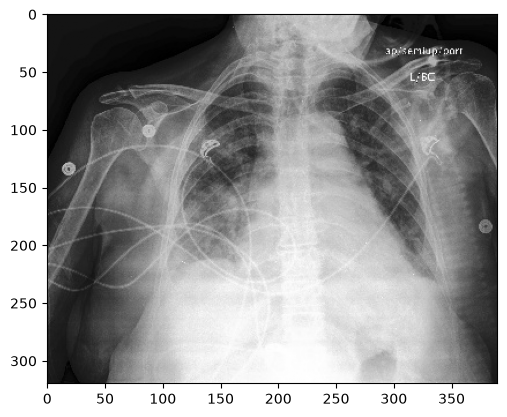

In [8]:
# one of the most important tasks:
# grayscale the images and resize them to a fixed size (e.g., 150x150 pixels) for consistency in training.

for i in categories:
    path = os.path.join(TRAIN_DIR, i)
    for img in os.listdir(path):
        img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
        plt.imshow(img_array, cmap="gray")
        plt.show()
        break
    break

In [9]:
img_size = 100
train_data = []

def create_train_data():
    for category in categories:
        path = os.path.join(TRAIN_DIR, category)
        class_num = categories.index(category)

        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                new_array = cv2.resize(img_array, (img_size, img_size))
                train_data.append([new_array, class_num])
                
            except Exception as e:
                pass

In [10]:
create_train_data()

In [11]:
print(len(train_data))

952


In [12]:
# shuffling the data to ensure that the model doesn't learn any order-based patterns
import random
random.shuffle(train_data)


In [13]:
# splitting the data into features and labels
X = []
y = []
for features, label in train_data:
    X.append(features)
    y.append(label)


In [14]:
# reshaping the data to fit the model's input requirements
X = np.array(X).reshape(-1, img_size, img_size, 1)
y = np.array(y)

# originally, the images are in grayscale, so they have a single channel. 
# The model expects input in the shape (num_samples, img_size, img_size, 1), where 1 indicates the single channel for grayscale images.
# why -1 in place of "number of images"?? because, it tells the model to automatically determine the number of samples based on the total size of the array and the specified dimensions (img_size, img_size, 1). 
# This is a common practice in machine learning to allow for flexibility in the number of samples.

In [16]:
# libraries for building the model

import tensorflow as tf
import keras
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Activation
import pickle

In [ ]:
# initialising the neural network model

model = tf.keras.models.Sequential()

model.add(Conv2D(64, (3, 3), input_shape=X.shape[1:])) #this line adds a convolutional layer with 64 filters of size 3x3. The input_shape parameter specifies the shape of the input data, which is derived from the shape of X (the training data). The [1:] slice is used to exclude the number of samples dimension, leaving only the height, width, and channels dimensions.
model.add(Activation("relu")) #this line adds an activation function to the model. The "relu" (Rectified Linear Unit) activation function is commonly used in convolutional neural networks because it introduces non-linearity, allowing the model to learn complex patterns in the data.
model.add(MaxPooling2D(pool_size=(2, 2)))#this is a pooling layer that reduces the spatial dimensions of the feature maps. It takes the maximum value from each 2x2 pool, effectively downsampling the feature maps and reducing the number of parameters in the model.
model.add(Dropout(0.2))

model.add(Conv2D(128, (3, 3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2)) 

model.add(Conv2D(256, (3, 3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2)) 

model.add(Flatten())
model.add(Dense(64))
model.add(Dense(1))
model.add(Activation("sigmoid"))

In [19]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 98, 98, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 98, 98, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 47, 47, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 47, 47, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 21, 21, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 21, 21, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     1,638,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,008,193 (7.66 MB)

 Trainable params: 2,008,193 (7.66 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
model.fit(X, y, batch_size=4, epochs=10, validation_split=0.2)

Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.4849 - loss: 10.9106 - val_accuracy: 0.4764 - val_loss: 0.6945
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.5099 - loss: 0.6965 - val_accuracy: 0.4660 - val_loss: 0.6937
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.5243 - loss: 0.7011 - val_accuracy: 0.4764 - val_loss: 0.6953
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.4796 - loss: 0.6961 - val_accuracy: 0.4712 - val_loss: 0.6937
Epoch 5/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.5112 - loss: 0.6954 - val_accuracy: 0.4712 - val_loss: 0.6934
Epoch 6/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.4915 - loss: 0.6979 - val_accuracy: 0.4555 - val_loss: 0.6929
Epoch 7/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.5204 - loss: 0.6951 - val_accuracy: 0.4921 - val_loss: 0.6942
Epoch 8/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.5125 - loss: 0.6840 - val_acc

In [21]:
model.save

<bound method Model.save of <Sequential name=sequential_1, built=True>>

In [22]:
from keras.models import load_model #load model is used to load a previously saved Keras model from disk. This allows you to reuse the trained model for making predictions or further training without having to retrain it from scratch.
import matplotlib.image as mpimg

In [23]:
def prepare(image):
    img_size = 100
    img = tf.keras.preprocessing.image.load_img(image, target_size=(img_size, img_size))
    new_array = tf.keras.preprocessing.image.img_to_array(img)

    return new_array.reshape(-1, img_size, img_size, 1)

In [ ]:
model = tf.keras.models.load_model("Pneumonia.model")